In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("default")



In [5]:
# Project root (notebook lives in outputs/dqn/)
PROJECT_ROOT = Path("..").resolve().parents[0]

DQN_OUT = PROJECT_ROOT / "outputs" / "dqn"

# Prefer episode-level log if exists
EP_LOG = DQN_OUT / "episode_log.csv"
STEP_LOG = DQN_OUT / "train_log.csv"


In [6]:
if EP_LOG.exists():
    df = pd.read_csv(EP_LOG)
    LOG_TYPE = "episode"
else:
    df = pd.read_csv(STEP_LOG)
    LOG_TYPE = "step"

LOG_TYPE, df.head()



('episode',
    timesteps  episode_return  episode_length  action_0_count  action_1_count  \
 0        256        -31672.8             256              78              91   
 1        512        -31546.8             256              96              76   
 2        768        -27088.8             256              79              82   
 3       1024        -30162.0             256              89              87   
 4       1280        -30884.4             256              74              88   
 
    action_2_count  action_0_share  action_1_share  action_2_share  
 0              87        0.304688        0.355469        0.339844  
 1              84        0.375000        0.296875        0.328125  
 2              95        0.308594        0.320312        0.371094  
 3              80        0.347656        0.339844        0.312500  
 4              94        0.289062        0.343750        0.367188  )

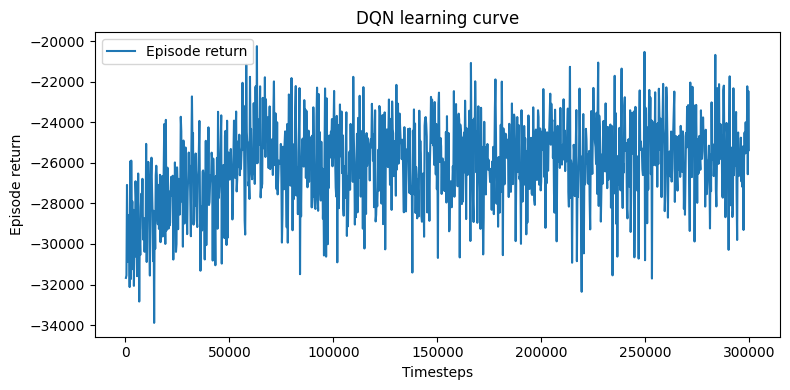

In [7]:
plt.figure(figsize=(8, 4))

if LOG_TYPE == "episode":
    plt.plot(df["timesteps"], df["episode_return"], label="Episode return")
    plt.ylabel("Episode return")
else:
    plt.plot(df["timesteps"], df["mean_reward"], label="Mean step reward")
    plt.ylabel("Reward")

plt.xlabel("Timesteps")
plt.title("DQN learning curve")
plt.legend()
plt.tight_layout()
plt.show()


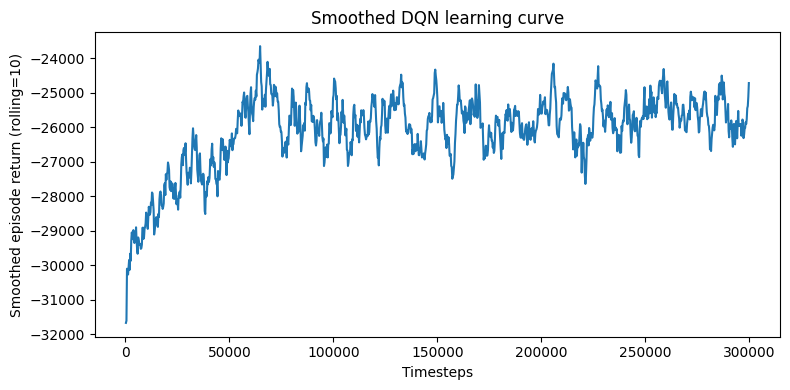

In [8]:
plt.figure(figsize=(8, 4))

if LOG_TYPE == "episode":
    smooth = df["episode_return"].rolling(window=10, min_periods=1).mean()
    plt.plot(df["timesteps"], smooth)
    plt.ylabel("Smoothed episode return (rolling=10)")
else:
    smooth = df["mean_reward"].rolling(window=10, min_periods=1).mean()
    plt.plot(df["timesteps"], smooth)
    plt.ylabel("Smoothed reward")

plt.xlabel("Timesteps")
plt.title("Smoothed DQN learning curve")
plt.tight_layout()
plt.show()


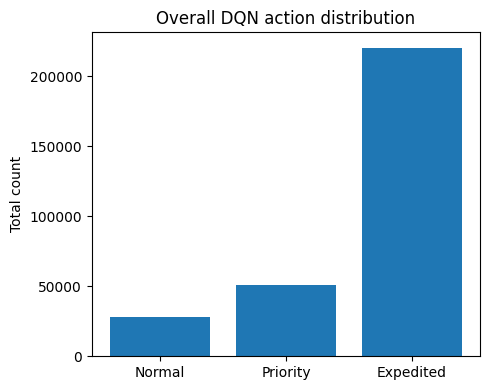

In [11]:
if LOG_TYPE == "episode":
    a0 = df["action_0_count"].sum()
    a1 = df["action_1_count"].sum()
    a2 = df["action_2_count"].sum()

    plt.figure(figsize=(5, 4))
    plt.bar(["Normal", "Priority", "Expedited"], [a0, a1, a2])
    plt.ylabel("Total count")
    plt.title("Overall DQN action distribution")
    plt.tight_layout()
    plt.show()
